## ENTENDER LOS DATOS
ENTENDER LA LÓGICA DEL NEGOCIO Y DEL EXPERIMENTO.

In [2]:
# G: Cargar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# G: CARGAR DATASETS
df_demo = pd.read_csv("/Users/gabrielbohorquez/Desktop/Ironhack/Semana_5/PROYECTO_2/Projecto-2-Vanguard-ab-test/data:/raw:/df_final_demo.txt")

df_web_pt1 = pd.read_csv("/Users/gabrielbohorquez/Desktop/Ironhack/Semana_5/PROYECTO_2/Projecto-2-Vanguard-ab-test/data:/raw:/df_final_experiment_clients.txt")

df_web_pt2 = pd.read_csv("/Users/gabrielbohorquez/Desktop/Ironhack/Semana_5/PROYECTO_2/Projecto-2-Vanguard-ab-test/data:/raw:/df_final_web_data_pt_1.txt")

df_experiment = pd.read_csv("/Users/gabrielbohorquez/Desktop/Ironhack/Semana_5/PROYECTO_2/Projecto-2-Vanguard-ab-test/data:/raw:/df_final_web_data_pt_2.txt")

In [5]:
# VERIFICAR DATASETS
print(df_demo.shape)
print(df_web_pt1.shape)
print(df_web_pt2.shape)
print(df_experiment.shape)

(70609, 9)
(70609, 2)
(343141, 5)
(412264, 5)


## MIRAR PRIMERAS FILAS DE CADA DATASET: 
DEMO - WEB_PT1 - WEB_PT2 - EXPERIMENT

In [28]:
# DEMO: información demográfica (edad, género, cuentas, balances, antigüedad)
df_demo.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [29]:
# WEB_PT1: (interacciones de los clientes con la web, como clicks, tiempo en la página, etc.)
df_web_pt1.head()

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control


In [30]:
# WEB_PT2: (interacciones de los clientes con la web, como clicks, tiempo en la página, etc.)
df_web_pt2.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [31]:
# EXPERIMENT: (clientes que participaron del experimento A/B)
df_experiment.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,763412,601952081_10457207388,397475557_40440946728_419634,confirm,2017-06-06 08:56:00
1,6019349,442094451_91531546617,154620534_35331068705_522317,confirm,2017-06-01 11:59:27
2,6019349,442094451_91531546617,154620534_35331068705_522317,step_3,2017-06-01 11:58:48
3,6019349,442094451_91531546617,154620534_35331068705_522317,step_2,2017-06-01 11:58:08
4,6019349,442094451_91531546617,154620534_35331068705_522317,step_1,2017-06-01 11:57:58


## ENTENDER COLUMNAS
DEMO - WEB_PT1 - WEB_PT2 - EXPERIMENT

In [13]:
# DEMO:
df_demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70609 non-null  int64  
 1   clnt_tenure_yr    70595 non-null  float64
 2   clnt_tenure_mnth  70595 non-null  float64
 3   clnt_age          70594 non-null  float64
 4   gendr             70595 non-null  object 
 5   num_accts         70595 non-null  float64
 6   bal               70595 non-null  float64
 7   calls_6_mnth      70595 non-null  float64
 8   logons_6_mnth     70595 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 4.8+ MB


In [14]:
# WEB_PT1:
df_web_pt1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  70609 non-null  int64 
 1   Variation  50500 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.1+ MB


In [15]:
# WEB_PT2:
df_web_pt2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343141 entries, 0 to 343140
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   client_id     343141 non-null  int64 
 1   visitor_id    343141 non-null  object
 2   visit_id      343141 non-null  object
 3   process_step  343141 non-null  object
 4   date_time     343141 non-null  object
dtypes: int64(1), object(4)
memory usage: 13.1+ MB


In [16]:
# EXPERIMENT:
df_experiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412264 entries, 0 to 412263
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   client_id     412264 non-null  int64 
 1   visitor_id    412264 non-null  object
 2   visit_id      412264 non-null  object
 3   process_step  412264 non-null  object
 4   date_time     412264 non-null  object
dtypes: int64(1), object(4)
memory usage: 15.7+ MB


## ESTADÍSTICAS GENERALES

In [18]:
# mean, std, min, max
df_demo.describe()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth
count,7.060900e+04,70595.000000,70595.000000,70594.000000,70595.000000,7.059500e+04,70595.000000,70595.000000
mean,5.004992e+06,12.052950,150.659367,46.442240,2.255528,1.474452e+05,3.382478,5.566740
std,2.877278e+06,6.871819,82.089854,15.591273,0.534997,3.015087e+05,2.236580,2.353286
min,1.690000e+02,2.000000,33.000000,13.500000,1.000000,1.378942e+04,0.000000,1.000000
25%,2.519329e+06,6.000000,82.000000,32.500000,2.000000,3.734683e+04,1.000000,4.000000
50%,5.016978e+06,11.000000,136.000000,47.000000,2.000000,6.333290e+04,3.000000,5.000000
75%,7.483085e+06,16.000000,192.000000,59.000000,2.000000,1.375449e+05,6.000000,7.000000
max,9.999839e+06,62.000000,749.000000,96.000000,8.000000,1.632004e+07,7.000000,9.000000


## REVISIÓN DE NULOS

In [20]:
# DEMO:
df_demo.isna().sum()

client_id            0
clnt_tenure_yr      14
clnt_tenure_mnth    14
clnt_age            15
gendr               14
num_accts           14
bal                 14
calls_6_mnth        14
logons_6_mnth       14
dtype: int64

In [21]:
# WEB_PT1:
df_web_pt1.isna().sum()

client_id        0
Variation    20109
dtype: int64

In [22]:
# WEB_PT2:
df_web_pt2.isna().sum()

client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64

In [23]:
# EXPERIMENT:
df_experiment.isna().sum()

client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64

## DUPLICADOS

In [24]:
# DEMO:
df_demo.duplicated().sum()

np.int64(0)

In [25]:
# WEB_PT1:
df_web_pt1.duplicated().sum()

np.int64(0)

In [26]:
# WEB_PT2:
df_web_pt2.duplicated().sum()

np.int64(2095)

In [27]:
# EXPERIMENT:
df_experiment.duplicated().sum()

np.int64(8669)

## VARIABLES IMPORTANTES
Explorar process_step
Porque?: La gran pregunta era: ¿Estas mejoras lograrán que más clientes completen el proceso? Se refiere al proceso DIGITAL QUE EL CLIENTE REALIZA EN LA WEB.
En el dataset aparece como: process_step Y los usuarios pasan por etapas como:
start
step_1
step_2
step_3
confirm
LO IMPORTANTE
El usuario NO “completa el proceso” solo por entrar. Lo completa si llega al paso final: "confirm"
Ese es el objetivo principal del negocio. ESO ES EL “COMPLETION RATE”

## VARIABLES??????
Explorar process_step
qué pasos existen
hay pasos raros?
el más frecuente?

## Explorar grupos experimentales
## PRIMERAS HIPÓTESIS
DATA CLEANING + MERGING?? (unir web_data_pt1 + pt2, convertir fechas, tratar nulos, validar joins, crear dataset final, preparar base analítica real)

In [42]:
# Explorar process_step
df_web_pt2["process_step"].value_counts()

process_step
start      108910
step_1      73432
step_2      61768
step_3      53628
confirm     45403
Name: count, dtype: int64

In [45]:
# Explorar grupos experimentales
df_web_pt1["Variation"].value_counts()

Variation
Test       26968
Control    23532
Name: count, dtype: int64

# Primeras hipótesis del análisis

## Hipótesis 1
Los usuarios del grupo Test tendrán mayor completion rate.

## Hipótesis 2
Los usuarios mayores podrían abandonar más el proceso.

## Hipótesis 3
El nuevo diseño podría reducir errores y pasos hacia atrás.

## Hipótesis 4
Clientes con más experiencia digital podrían completar más fácilmente.

## Distribución de edades

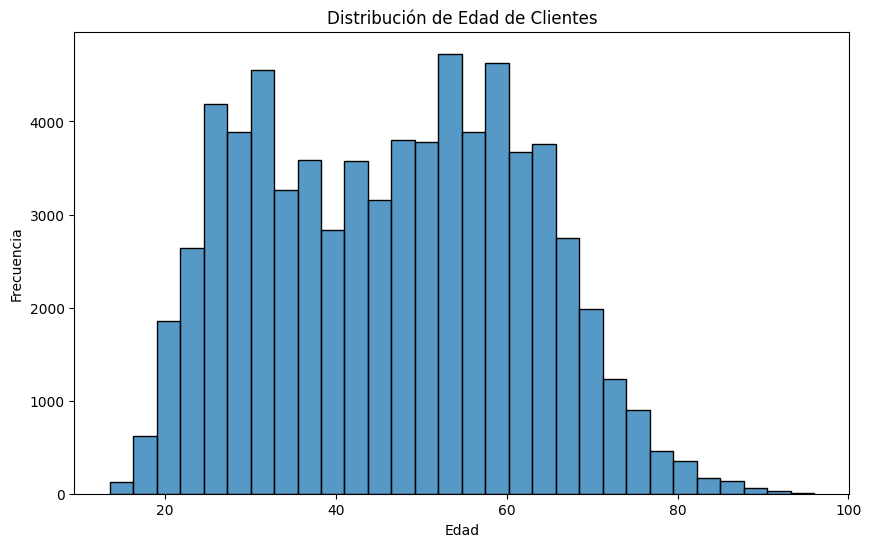

In [47]:
# Visualizar distribución de edad de clientes
plt.figure(figsize=(10,6))

sns.histplot(df_demo["clnt_age"], bins=30)

plt.title("Distribución de Edad de Clientes")

plt.xlabel("Edad")

plt.ylabel("Frecuencia")

plt.show()

La mayoría de clientes tienen entre 25 y 60 años
Pico doble alrededor de los 30 y 50-55 años
Distribución sesgada a la derecha — pocos clientes mayores de 70

## Balance Test vs Control

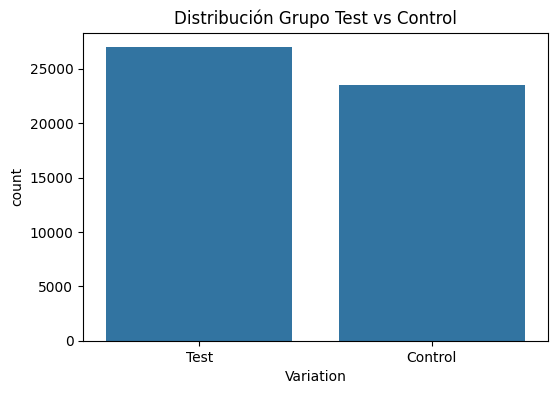

In [49]:
plt.figure(figsize=(6,4))

sns.countplot(data=df_web_pt1, x="Variation")

plt.title("Distribución Grupo Test vs Control")

plt.show()

Test: 26,000 usuarios
Control: 23,000 usuarios

Los grupos están bastante balanceados, lo cual es bueno para el A/B test — no hay sesgo significativo en la asignación.